In [1]:
import numpy as np

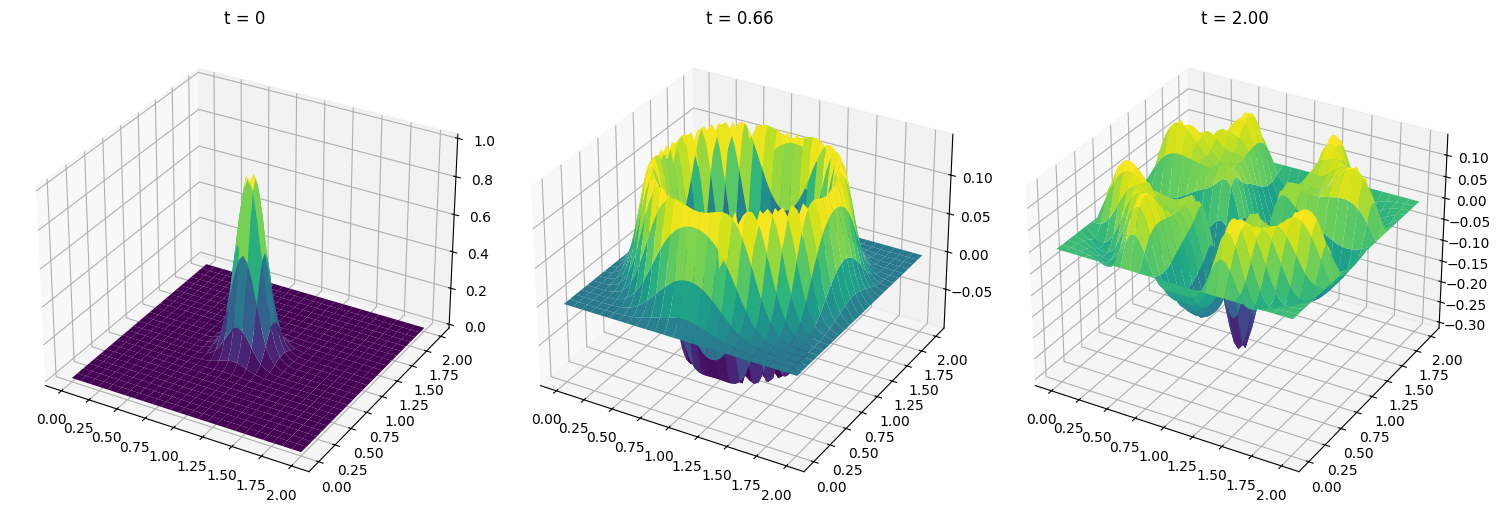

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def solve_wave_equation_2d(Lx, Ly, T, nx, ny, nt, f, g):
    """
    Численное решение 2D волнового уравнения
    """
    # Параметры сетки
    dx = Lx / (nx - 1)
    dy = Ly / (ny - 1)
    dt = T / (nt - 1)
    
    # Проверка устойчивости
    if dt > min(dx, dy) / np.sqrt(2):
        dt = min(dx, dy) / np.sqrt(2) * 0.9
        nt = int(T / dt) + 1
        print(f"Скорректированный шаг по времени: {dt}")
    
    # Коэффициенты
    cx = (dt / dx)**2
    cy = (dt / dy)**2
    
    # Инициализация
    u = np.zeros((nt, nx, ny))
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    # Начальные условия
    u[0] = f(X, Y)
    
    # Первый шаг (используем начальную скорость)
    u[1] = u[0] + dt * g(X, Y)
    
    # Основной цикл
    for n in range(1, nt - 1):
        for i in range(1, nx - 1):
            for j in range(1, ny - 1):
                u[n+1, i, j] = (2 * u[n, i, j] - u[n-1, i, j] +
                               cx * (u[n, i+1, j] - 2*u[n, i, j] + u[n, i-1, j]) +
                               cy * (u[n, i, j+1] - 2*u[n, i, j] + u[n, i, j-1]))
        
        # Граничные условия (закрепленные края)
        u[n+1, 0, :] = 0
        u[n+1, -1, :] = 0
        u[n+1, :, 0] = 0
        u[n+1, :, -1] = 0
    
    return u, x, y, dt

# Пример использования
def example():
    Lx, Ly = 2.0, 2.0  # Размеры области
    T = 2.0            # Время моделирования
    nx, ny = 51, 51    # Количество узлов
    nt = 200           # Количество шагов по времени
    
    # Начальные условия - гауссов импульс
    def f(x, y):
        x0, y0 = Lx/2, Ly/2
        return np.exp(-40*((x-x0)**2 + (y-y0)**2))
    
    def g(x, y):
        return np.zeros_like(x)  # Нулевая начальная скорость
    
    # Решение
    u, x, y, dt = solve_wave_equation_2d(Lx, Ly, T, nx, ny, nt, f, g)
    
    # Визуализация
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    fig = plt.figure(figsize=(15, 5))
    
    # Начальное состояние
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot_surface(X, Y, u[0], cmap='viridis')
    ax1.set_title('t = 0')
    
    # Промежуточное состояние
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(X, Y, u[nt//3], cmap='viridis')
    ax2.set_title(f't = {nt//3 * dt:.2f}')
    
    # Конечное состояние
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot_surface(X, Y, u[-1], cmap='viridis')
    ax3.set_title(f't = {T:.2f}')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    example()

Создание 3D анимации...


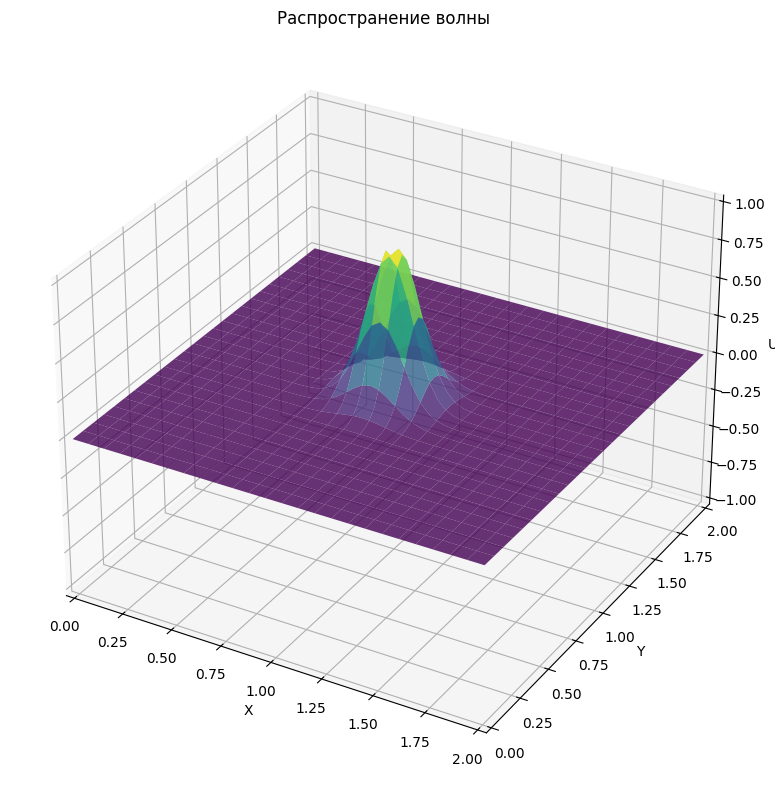

c:\Users\Amik29\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


Создание 2D анимации...
Создание сравнительной анимации...


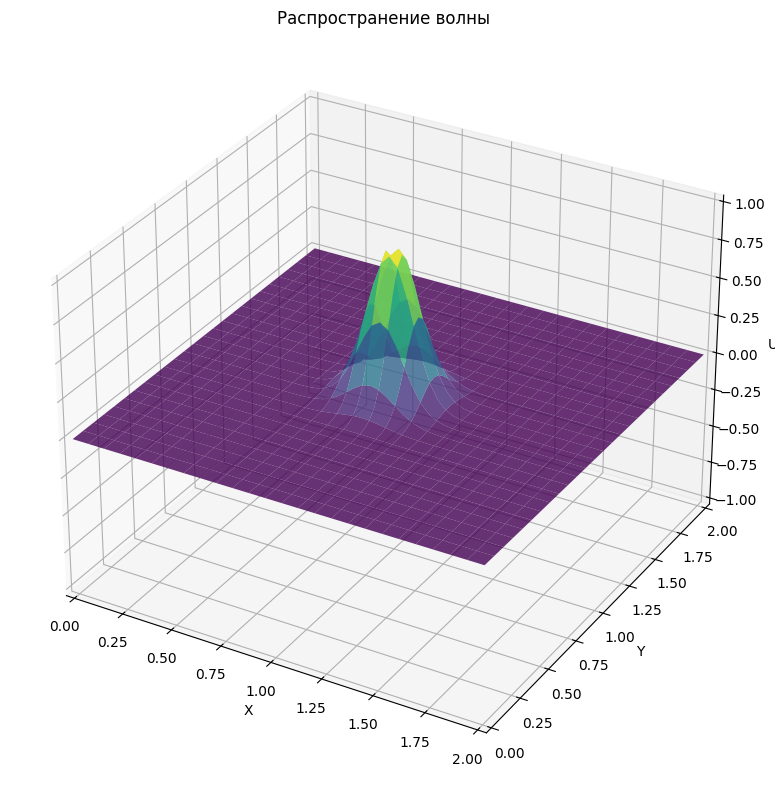

MovieWriter ffmpeg unavailable; using Pillow instead.


Анимация сохранена как 'wave_equation.gif'
Для сохранения MP4 установите ffmpeg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

def solve_wave_equation_2d(Lx, Ly, T, nx, ny, nt, f, g):
    """
    Численное решение 2D волнового уравнения
    """
    # Параметры сетки
    dx = Lx / (nx - 1)
    dy = Ly / (ny - 1)
    dt = T / (nt - 1)
    
    # Проверка устойчивости
    if dt > min(dx, dy) / np.sqrt(2):
        dt = min(dx, dy) / np.sqrt(2) * 0.9
        nt = int(T / dt) + 1
        print(f"Скорректированный шаг по времени: {dt}")
    
    # Коэффициенты
    cx = (dt / dx)**2
    cy = (dt / dy)**2
    
    # Инициализация
    u = np.zeros((nt, nx, ny))
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    # Начальные условия
    u[0] = f(X, Y)
    
    # Первый шаг (используем начальную скорость)
    u[1] = u[0] + dt * g(X, Y)
    
    # Основной цикл
    for n in range(1, nt - 1):
        for i in range(1, nx - 1):
            for j in range(1, ny - 1):
                u[n+1, i, j] = (2 * u[n, i, j] - u[n-1, i, j] +
                               cx * (u[n, i+1, j] - 2*u[n, i, j] + u[n, i-1, j]) +
                               cy * (u[n, i, j+1] - 2*u[n, i, j] + u[n, i, j-1]))
        
        # Граничные условия
        u[n+1, 0, :] = 0
        u[n+1, -1, :] = 0
        u[n+1, :, 0] = 0
        u[n+1, :, -1] = 0
    
    return u, x, y, X, Y, dt

def create_animation_3d():
    """Создание 3D анимации"""
    # Параметры
    Lx, Ly = 2.0, 2.0
    T = 3.0
    nx, ny = 51, 51
    nt = 300
    
    # Начальные условия - гауссов импульс
    def f(x, y):
        x0, y0 = Lx/2, Ly/2
        return np.exp(-40*((x-x0)**2 + (y-y0)**2))
    
    def g(x, y):
        return np.zeros_like(x)
    
    # Решение
    u, x, y, X, Y, dt = solve_wave_equation_2d(Lx, Ly, T, nx, ny, nt, f, g)
    
    # Создание анимации
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Настройка графика
    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_zlim(-1, 1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('U')
    ax.set_title('Распространение волны')
    
    # Первый кадр
    surf = ax.plot_surface(X, Y, u[0], cmap='viridis', alpha=0.8)
    
    def animate(frame):
        ax.clear()
        ax.set_xlim(0, Lx)
        ax.set_ylim(0, Ly)
        ax.set_zlim(-0.5, 0.5)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('U')
        ax.set_title(f'Время: {frame*dt:.2f} с')
        
        surf = ax.plot_surface(X, Y, u[frame], cmap='coolwarm', 
                              alpha=0.8, linewidth=0, antialiased=True)
        return surf,
    
    # Создание анимации
    anim = FuncAnimation(fig, animate, frames=nt, interval=50, blit=False, repeat=True)
    
    plt.tight_layout()
    plt.show()
    
    return anim

def create_animation_2d():
    # Параметры
    Lx, Ly = 2.0, 2.0
    T = 3.0
    nx, ny = 51, 51
    nt = 300
    
    def f(x, y):
        x1, y1 = Lx/3, Ly/2
        return (np.exp(-80*((x-x1)**2 + (y-y1)**2)))
    
    def g(x, y):
        return np.zeros_like(x)
    
    # Решение
    u, x, y, X, Y, dt = solve_wave_equation_2d(Lx, Ly, T, nx, ny, nt, f, g)
    
    # Создание анимации
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Первый кадр
    im = ax.imshow(u[0].T, extent=[0, Lx, 0, Ly], origin='lower', 
                   cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    plt.colorbar(im, ax=ax, label='Амплитуда')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Распространение волны')
    
    def animate(frame):
        ax.clear()
        im = ax.imshow(u[frame].T, extent=[0, Lx, 0, Ly], origin='lower', 
                      cmap='RdBu_r', vmin=-0.3, vmax=0.3)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'Время: {frame*dt:.2f} с')
        return im,
    
    anim = FuncAnimation(fig, animate, frames=nt, interval=50, blit=False, repeat=True)
    
    plt.tight_layout()
    plt.show()
    
    return anim


def save_animation():
    anim = create_animation_3d()
    
    try:
        anim.save('wave_equation.gif', writer='pillow', fps=20)
        print("Анимация сохранена как 'wave_equation.gif'")
    except:
        print("Для сохранения GIF установите: pip install pillow")
    
    # Сохранение как MP4 (требуется ffmpeg)
    try:
        anim.save('wave_equation.mp4', writer='ffmpeg', fps=20)
        print("Анимация сохранена как 'wave_equation.mp4'")
    except:
        print("Для сохранения MP4 установите ffmpeg")


if __name__ == "__main__":
    print("Создание 3D анимации...")
    anim_3d = create_animation_3d()
    
    print("Создание 2D анимации...")
    #anim_2d = create_animation_2d()
    
    print("Создание сравнительной анимации...")
    # anim_comp = create_comparison_animation()
    
    # Сохранение анимации
    save_animation()